In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from plot_hourly_energy import (
    plot_hourly_energy,
    plot_hourly_energy_overlay,
    find_runs,
    aggregate_runs,
    plot_cumulative_rewards_multi,
    plot_cumulative_rewards,
    plot_rewards_comparison,
    plot_scenario_metrics_box,
    plot_daily_energy_summary
)

from plot_hourly_energy import plot_hourly_clearing_price


In [2]:
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.titlesize": 18,   # ← controla suptitle
})

In [3]:
FR_DR = "../exp_results_repro/fr_dr"
FR_NAIVE = "../exp_results_repro/fr_naive"
FR_ORACLE = "../exp_results_repro/fr_oracle"

In [4]:
def plot_analysis(exp_path, case, seed=None, ylim=(0,1200)):
    figsize = (10,6)
    if seed is not None:
        title1 = f"Reward comparison - {case}: Best seed {seed}"
        title2 = f"Energy Balance - {case}: Best seed {seed}"
        title3 = f"Prices - {case}: Best seed {seed}"
    else: 
        title1 = f"Reward comparison - {case}: Mean over all seeds"
        title2 = f"Energy Balance - {case}: Mean over all seeds"
        title3 = f"Prices - {case}: Mean over all seeds"
    fig, ax, _ = plot_cumulative_rewards(exp_path, title=title1, figsize=figsize, ylim=ylim, seed=seed)
    df_avg = plot_hourly_energy_overlay(exp_path, title=title2, figsize=figsize, seed=seed)
    df_seed = plot_hourly_clearing_price(
        exp_path, title=title3, figsize=figsize,
        profiles_json_path="../profiles/agents_profiles_24h.json",
        seed=seed,band="minmax", show_volume_prediction=False, show_p2p_volume=False
    )
    plt.show()


[Oracle]
        seed    total   jain   gini lossN  score passed
seed44_run23   2654.4 0.8031 0.2630    0% 1.0000      ✓
seed42_run21   2636.4 0.7725 0.2811    0% 0.9255      ✓
seed51_run30   2649.9 0.7627 0.2875    0% 0.9120      ✓
seed49_run28   2547.5 0.7746 0.2880    0% 0.8731      ✓
seed46_run25   2122.2 0.7405 0.3226    0% 0.5496      ✓
seed47_run26   2503.6 0.6256 0.3997    0% 0.5153      ✓
seed45_run24   2326.1 0.4939 0.5057    0% 0.1149      ✓
seed43_run22   1606.2 0.7182 0.3371   17%      —      ✗
seed48_run27   2329.9 0.4833 0.5157   17%      —      ✗
seed50_run29   2458.7 0.4651 0.5261   17%      —      ✗
  → mejor: seed44_run23  (score=1.0000)

[Naive]
        seed    total   jain   gini lossN  score passed
seed46_run15   2603.2 0.8292 0.2530    0% 0.9201      ✓
seed51_run20   2649.9 0.7727 0.2755    0% 0.8931      ✓
seed42_run11   2474.6 0.8135 0.2587    0% 0.6707      ✓
seed48_run17   2526.4 0.7632 0.2793    0% 0.6636      ✓
seed47_run16   2553.0 0.7426 0.3143    0% 0.6

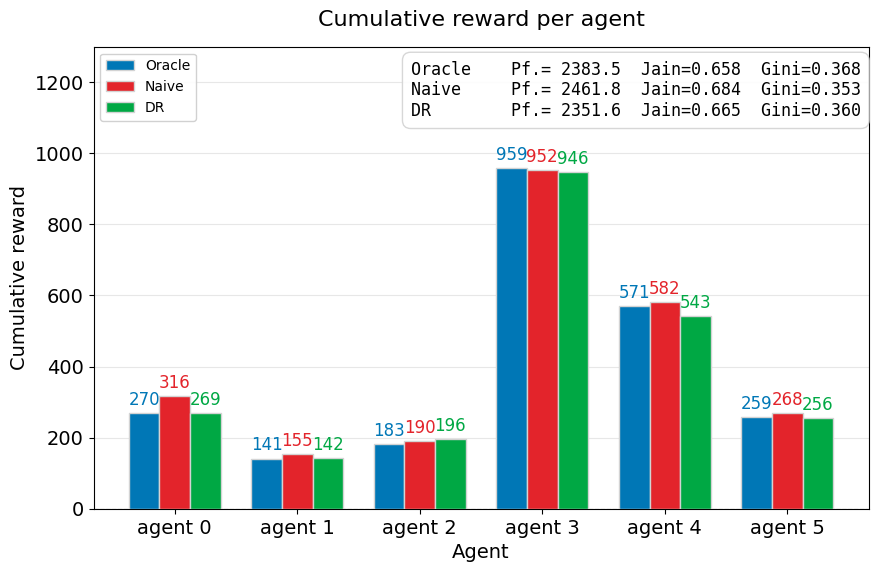

In [7]:
fig, ax, metrics = plot_cumulative_rewards_multi(
    scenario_dirs=[
        FR_DR,
        FR_NAIVE,
        FR_ORACLE,
    ],
    labels=["Oracle", "Naive", "DR"],
    ylim=(0, 1300),
    figsize=(10,6)
)

# Resultados Paper

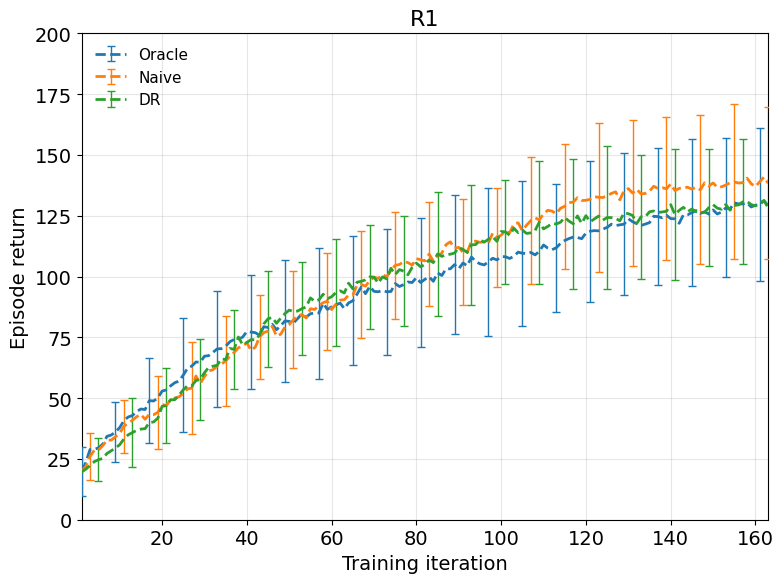

In [14]:
y_lim = (0,200)

plot_rewards_comparison(
    scenario_dir=[FR_ORACLE, FR_NAIVE, FR_DR],
    seed_aggregation="mean",
    labels=["Oracle", "Naive", "DR"],
    title="R1",
    ylim=y_lim,
    band_style="errorbar",
    error_metric="seed_std",   # dispersión entre semillas
    errorevery=8,
    capsize=3,
    linestyle="--",
    figsize=(8,6),
    colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
)

plt.tight_layout()
plt.show()

fig.savefig("plots/fig_training_courves.pdf", bbox_inches="tight")

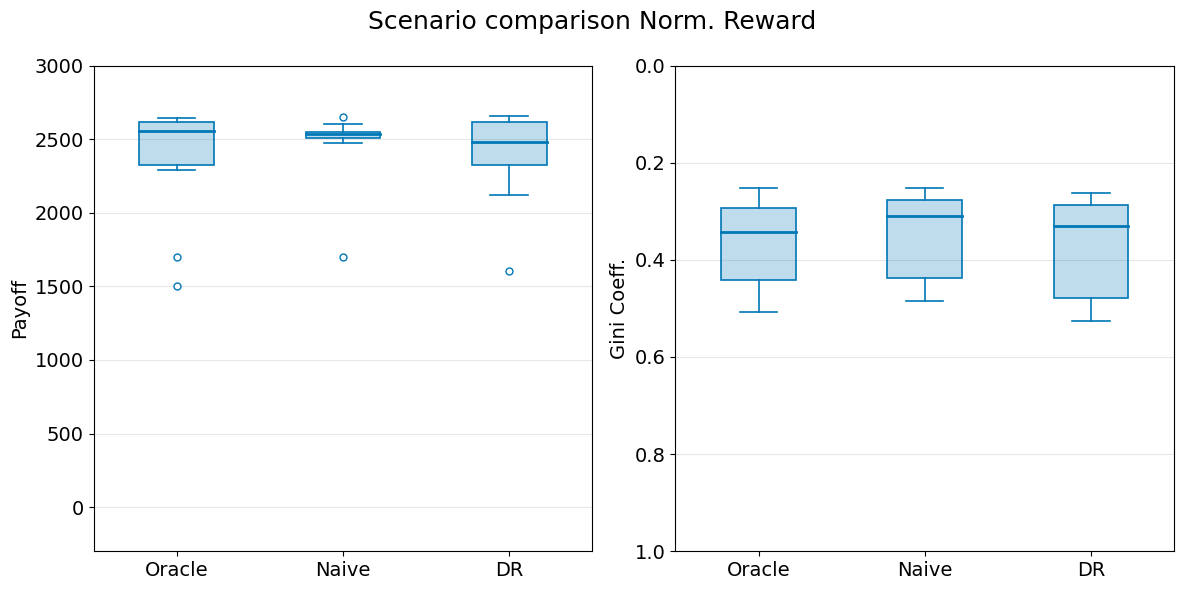

In [19]:


ylim_total = (-300,3000)

plot_scenario_metrics_box(
    scenario_dirs=[
        FR_ORACLE,
        FR_NAIVE,
        FR_DR,
    ],
    labels=["Oracle", "Naive", "DR"],
    title="Scenario comparison Norm. Reward",
    show_points=False,
    ylim_gini=(1,0),
    ylim_jain=(0,1),
    ylim_total=ylim_total,
    n_figures=2,
    figsize=(12,6)
)


plt.tight_layout()
plt.show()

fig.savefig("plots/fig_multiseed_evaluation.pdf", bbox_inches="tight")

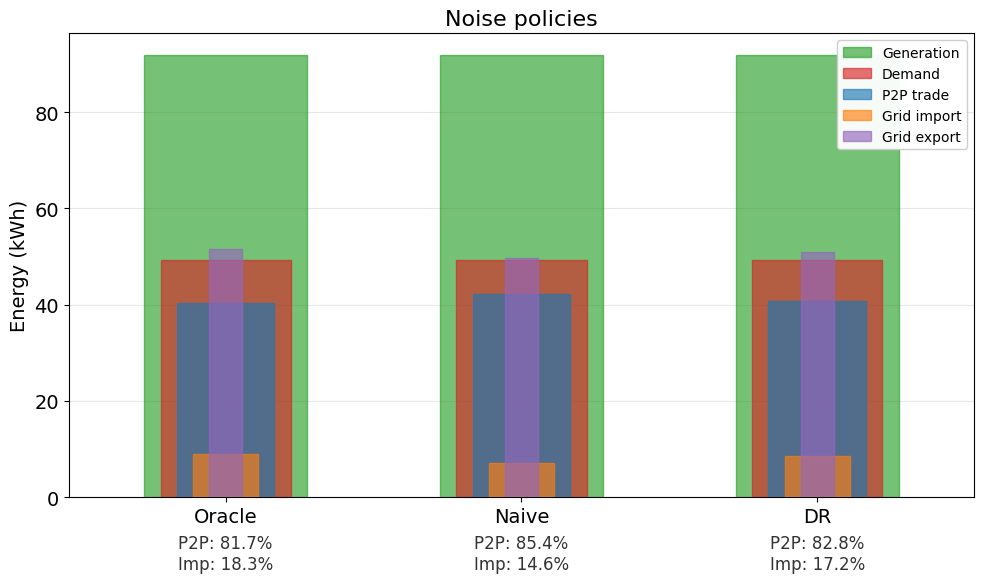

In [20]:


plot_daily_energy_summary(
    scenario_dirs=[
        FR_ORACLE,
        FR_NAIVE,
        FR_DR,
    ],
    labels=["Oracle", "Naive", "DR"],
    title="Noise policies",
)

plt.tight_layout()
plt.show()

fig.savefig("plots/fig_energy_summary.pdf", bbox_inches="tight")

\begin{table*}[t]
\centering
\caption{Performance of the nine experimental configurations, reported as mean $\pm$ standard deviation over 10 seeds. Payoff is the community economic payoff; Jain and Gini are performance measures on the realised payoff distribution, distinct from the welfare signals used inside the reward. Best value of each metric in bold.}
\label{tab:factorial_results}
\begin{tabular}{lccccccccc}
\toprule
\textbf{Reward} & \multicolumn{3}{c}{\textbf{S1}} & \multicolumn{3}{c}{\textbf{S2}} & \multicolumn{3}{c}{\textbf{S3}} \\
\cmidrule(lr){2-4}\cmidrule(lr){5-7}\cmidrule(lr){8-10}
 & Payoff & Jain & Gini & Payoff & Jain & Gini & Payoff & Jain & Gini \\
\midrule
\textbf{R1} & 1875 $\pm$ 709 & 0.387 $\pm$ 0.121 & 2291 $\pm$ 444 & 0.381 $\pm$ 0.099 & 2107 $\pm$ 441 & 0.376 $\pm$ 0.088 \\
\textbf{R2} & 1864 $\pm$ 543 & 0.418 $\pm$ 0.101 & \textbf{2344 $\pm$ 334} & 0.369 $\pm$ 0.103 & 2126 $\pm$ 568 & \textbf{0.314 $\pm$ 0.068} \\
\textbf{R3} & -70 $\pm$ 10 & 0.323 $\pm$ 0.00

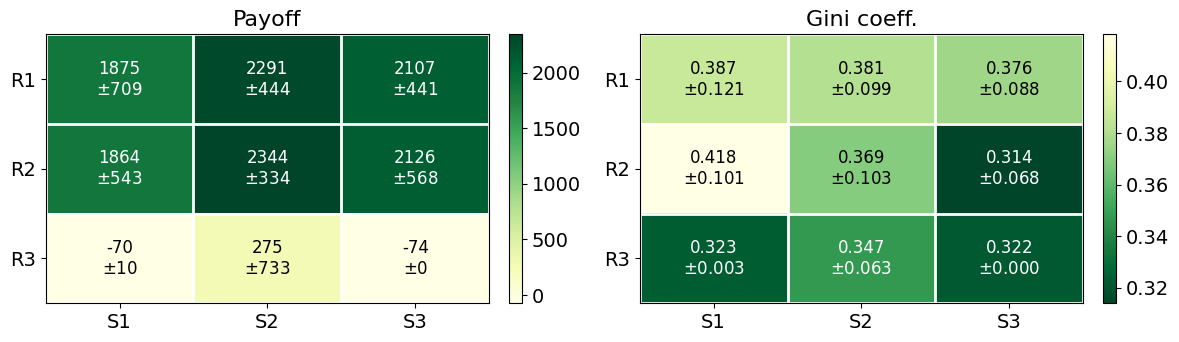

In [10]:
from plot_factorial_summary import (
    collect_factorial_metrics, factorial_table_latex, plot_factorial_heatmap,
)

base = "../exp_results_repro"
dir_grid = {
    ("R1", "S1"): f"{base}/final_tesis_norm_reward_total_obs",
    ("R1", "S2"): f"{base}/final_tesis_norm_reward_partial_obs",
    ("R1", "S3"): f"{base}/final_tesis_norm_reward_local_obs",
    # ("R2", "S1"): f"{base}/final_tesis_gini_reward_total_obs",
    # ("R2", "S2"): f"{base}/final_tesis_gini_reward_partial_obs",
    # ("R2", "S3"): f"{base}/final_tesis_gini_reward_local_obs",
    ("R2", "S1"): f"{base}/final_tesis_jain_reward_total_obs",
    ("R2", "S2"): f"{base}/final_tesis_jain_reward_partial_obs",
    ("R2", "S3"): f"{base}/final_tesis_jain_reward_local_obs",
    ("R3", "S1"): f"{base}/final_tesis_jain_only_reward_total_obs",
    ("R3", "S2"): f"{base}/final_tesis_jain_only_reward_partial_obs",
    ("R3", "S3"): f"{base}/final_tesis_jain_only_reward_local_obs",
}

cell_stats = collect_factorial_metrics(dir_grid)

# Tabla LaTeX (imprime el bloque listo para pegar; pásale p2p_share si lo tienes):
print(factorial_table_latex(cell_stats))

# Heatmap:
fig, axes = plot_factorial_heatmap(cell_stats)
fig.suptitle("")
fig.savefig("plots/fig_factorial_heatmap.png", bbox_inches="tight")

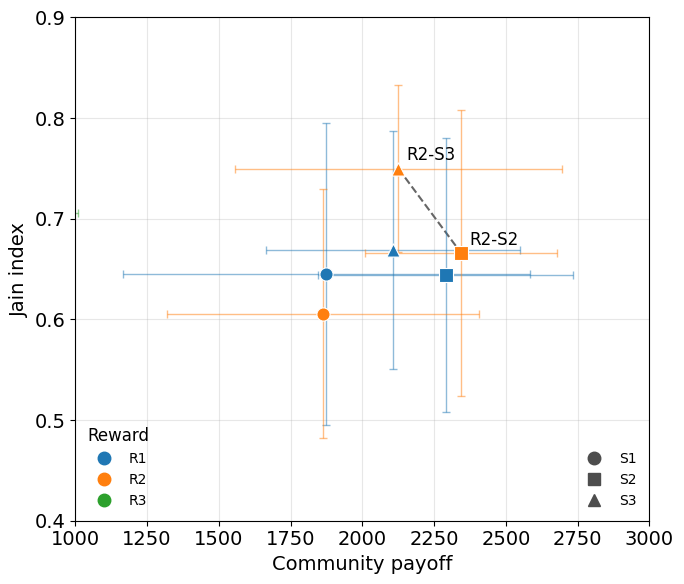

In [6]:
from plot_factorial_summary import plot_tradeoff_scatter

from plot_factorial_summary import (
    collect_factorial_metrics, factorial_table_latex, plot_factorial_heatmap,
)

base = "../exp_results_repro"
dir_grid = {
    ("R1", "S1"): f"{base}/final_tesis_norm_reward_total_obs",
    ("R1", "S2"): f"{base}/final_tesis_norm_reward_partial_obs",
    ("R1", "S3"): f"{base}/final_tesis_norm_reward_local_obs",
    # ("R2", "S1"): f"{base}/final_tesis_gini_reward_total_obs",
    # ("R2", "S2"): f"{base}/final_tesis_gini_reward_partial_obs",
    # ("R2", "S3"): f"{base}/final_tesis_gini_reward_local_obs",
    ("R2", "S1"): f"{base}/final_tesis_jain_reward_total_obs",
    ("R2", "S2"): f"{base}/final_tesis_jain_reward_partial_obs",
    ("R2", "S3"): f"{base}/final_tesis_jain_reward_local_obs",
    ("R3", "S1"): f"{base}/final_tesis_jain_only_reward_total_obs",
    ("R3", "S2"): f"{base}/final_tesis_jain_only_reward_partial_obs",
    ("R3", "S3"): f"{base}/final_tesis_jain_only_reward_local_obs",
}

cell_stats = collect_factorial_metrics(dir_grid)

# Una sola métrica de equidad:
fig, ax = plot_tradeoff_scatter(cell_stats, equity="jain", ylim=(0.4,0.9), xlim=(1000,3000))
fig.savefig("plots/fig_tradeoff_jain.pdf", bbox_inches="tight")

# # O las dos lado a lado:
# import matplotlib.pyplot as plt
# fig, axes = plt.subplots(1, 2, figsize=(13, 6))
# plot_tradeoff_scatter(cell_stats, equity="jain", ax=axes[0], ylim=(0,1))
# plot_tradeoff_scatter(cell_stats, equity="gini", ax=axes[1])
# fig.tight_layout()
# fig.savefig("plots/fig_tradeoff.pdf", bbox_inches="tight")

In [14]:
dir_grid = {
    ("R1", "S1"): f"{base}/R1-S1",
    ("R1", "S2"): f"{base}/R1-S2",
    ("R1", "S3"): f"{base}/R1-S3",
    # ("R2", "S1"): f"{base}/final_tesis_gini_reward_total_obs",
    # ("R2", "S2"): f"{base}/final_tesis_gini_reward_partial_obs",
    # ("R2", "S3"): f"{base}/final_tesis_gini_reward_local_obs",
    ("R2", "S1"): f"{base}/R2-S1",
    ("R2", "S2"): f"{base}/R2-S2",
    ("R2", "S3"): f"{base}/R2-S3",
    ("R3", "S1"): f"{base}/R3-S1",
    ("R3", "S2"): f"{base}/R3-S2",
    ("R3", "S3"): f"{base}/R3-S3",
}
cell_stats = collect_factorial_metrics(dir_grid)

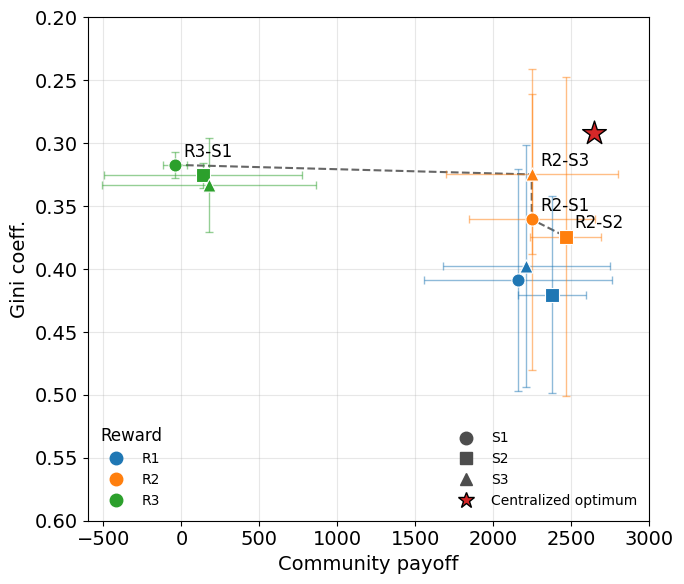

In [15]:
from plot_factorial_summary import baseline_point, plot_tradeoff_scatter

baselines = {
    "Centralized optimum": baseline_point(f"../exp_results_repro/centralized_exp/centralized_midpoint/evaluation_agent_states.csv"),
    # "Midpoint heuristic":  baseline_point(f"../exp_results_repro/heuristic_midpoint/heuristic_midpoint/evaluation_agent_states.csv"),
}
fig, ax = plot_tradeoff_scatter(
    cell_stats, equity="gini", baselines=baselines,
    xlim=(-600, 3000), ylim=(0.6, 0.2),
)
fig.savefig("plots/fig_tradeoff_baselines.pdf", bbox_inches="tight")

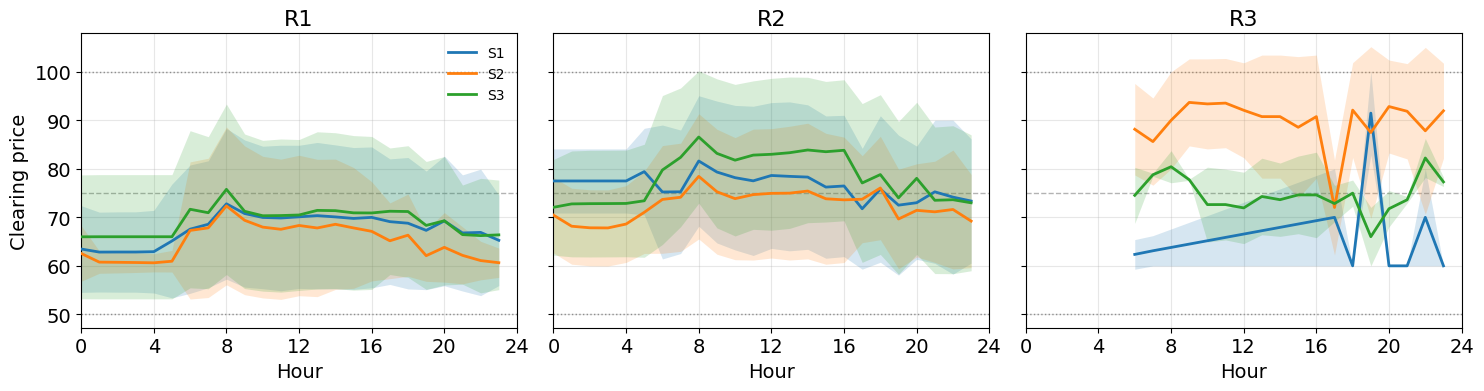

In [16]:
from plot_factorial_summary import plot_clearing_price_grid

fig, ax = plot_clearing_price_grid(
    dir_grid,                                  # el (reward, scenario) -> dir que ya tienes
    profiles_json_path="../profiles/agents_profiles_24h.json",
    lambda_sell=50.0, lambda_buy=100.0,
)
fig.suptitle("")
fig.savefig("plots/fig_clearing_price.pdf", bbox_inches="tight")

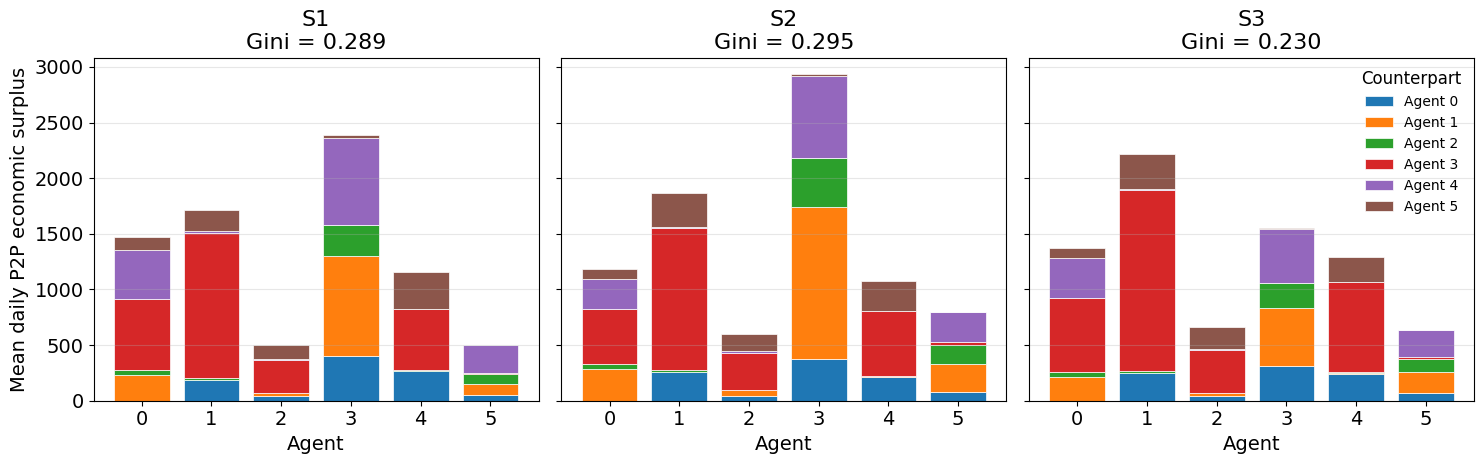

In [19]:
from plot_factorial_summary import plot_agent_surplus

base = "../exp_results_repro"

flow_grid = {
    "S1": f"{base}/R2-S1",
    "S2": f"{base}/R2-S2",
    "S3": f"{base}/R2-S3",
}

fig, ax = plot_agent_surplus(
    flow_grid, lambda_sell=50.0, lambda_buy=100.0,
    # title="Per-agent P2P surplus, stacked by counterpart — R3 Jain",
)
fig.savefig("plots/fig_agent_surplus.pdf", bbox_inches="tight")